In [ ]:
import os
print(os.getcwd())
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from torchvision import models
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix


if os.path.isdir('/content/drive/MyDrive/CS659 Project/preprocessed'):
    print("Directory exists")

print("cuda available:", torch.cuda.is_available())
print("device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
!nvidia-smi

/content
Directory exists
cuda available: True
device: cuda
Mon Apr 27 21:57:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |            

In [ ]:
class NpyDataset(Dataset):
    def __init__(self, X_path, y_path):
        X = np.load(X_path)  # (N, H, W, C)
        y = np.load(y_path)
        print(y_path)
        print("unique labels:", np.unique(y), "count:", len(y))

        self.X = torch.from_numpy(X).float()  # keep as (N, H, W, C)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]          # (H, W, C)
        x = x.permute(2, 0, 1)   # -> (C, H, W) channels-first [web:133][web:135]
        return x, self.y[idx]

train_ds = NpyDataset("/content/drive/MyDrive/CS659 Project/preprocessed/train_X.npy", "/content/drive/MyDrive/CS659 Project/preprocessed/train_y.npy")
test_ds  = NpyDataset("/content/drive/MyDrive/CS659 Project/preprocessed/test_X.npy",  "/content/drive/MyDrive/CS659 Project/preprocessed/test_y.npy")

test_full_len = len(test_ds)
val_len = test_full_len // 2                # 1146
test_len = test_full_len - val_len          # 1146 (handles odd numbers safely)

val_ds, final_test_ds = random_split(
    test_ds,
    lengths=[val_len, test_len],
    generator=torch.Generator().manual_seed(42)  # for reproducibility
)

print("Val size:", len(val_ds))
print("Final test size:", len(final_test_ds))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(final_test_ds,  batch_size=32, shuffle=False)

num_classes = 4

/content/drive/MyDrive/CS659 Project/preprocessed/train_y.npy
unique labels: [0 1 2 3] count: 10604
/content/drive/MyDrive/CS659 Project/preprocessed/test_y.npy
unique labels: [0 1 2 3] count: 2652
Val size: 1326
Final test size: 1326


In [ ]:
# 2. Model: pretrained ResNet-50 + new 4-class head
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features

# model.fc = nn.Linear(in_features, num_classes)  # simple baseline head
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    # nn.Dropout(p=0.5),
    nn.Dropout(p=0.20),
    nn.Linear(512, num_classes)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.7MB/s]


In [ ]:
# 3. Freeze backbone (baseline = feature extractor)
for name, param in model.named_parameters():
    if not name.startswith("fc."):
        param.requires_grad = False

# Only the head parameters will be updated
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
# Adjust LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
x_batch, y_batch = next(iter(train_loader))
print("Batch shape:", x_batch.shape, y_batch.shape)
print("Device:", device)

Batch shape: torch.Size([32, 3, 224, 224]) torch.Size([32])
Device: cuda


In [ ]:
# 4. Training + validation loop (baseline)
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

checkpoint_dir = "/content/drive/MyDrive/CS659 Project/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_checkpoint_path = os.path.join(checkpoint_dir, "resnet_best.pt")

if os.path.isfile(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_val_acc = checkpoint.get("val_acc", -float("inf"))
    print(f"Found checkpoint. best_val_acc = {best_val_acc:.4f}")
else:
    best_val_acc = -float("inf")  # or use +inf with val_loss if you monitor loss
    print("No best checkpoint found. Starting fresh.")

No best checkpoint found. Starting fresh.


In [ ]:
# RUN IF STARTING TRAINING, OTHERWISE SKIP
num_epochs = 30
start_epoch = 0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

training_start = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = evaluate(model, val_loader,   criterion)

    scheduler.step(val_loss)  # Adjusts LR if val_loss plateaued

    epoch_time = time.time() - epoch_start

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch+1)%5 == 0:
      print(f"Epoch {epoch+1:02d}: "
            f"(time={epoch_time:.1f}s): "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

      ckpt_path = os.path.join(checkpoint_dir, f"resnet_epoch_{epoch+1}.pt")
      torch.save({
          "epoch": epoch + 1,
          "model_state": model.state_dict(),
          "optimizer_state": optimizer.state_dict(),
          "train_loss": train_loss,
          "val_loss": val_loss,
          "train_acc": train_acc,
          "val_acc": val_acc,
      }, ckpt_path)
      print(f"Saved checkpoint: {ckpt_path}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save({
          "epoch": epoch + 1,
          "model_state": model.state_dict(),
          "optimizer_state": optimizer.state_dict(),
          "train_loss": train_loss,
          "val_loss": val_loss,
          "train_acc": train_acc,
          "val_acc": val_acc,
      }, best_checkpoint_path)
      print(f"New best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

print(f"Total training time: {time.time() - training_start:.1f}s")

history = pd.DataFrame({
    "epoch": list(range(1, num_epochs + 1)),
    "train_loss": train_losses,
    "train_acc": train_accuracies,
    "val_loss": val_losses,
    "val_acc": val_accuracies,
})

results_dir = "/content/drive/MyDrive/CS659 Project/results"
os.makedirs(results_dir, exist_ok=True)

history.to_csv(Path(results_dir) / "resnet_history.csv", index=False)
print("Saved training history to CSV.")

New best model at epoch 1 with val_acc=0.8982
New best model at epoch 2 with val_acc=0.9072
Epoch 05: (time=43.4s): train_loss=0.5753, train_acc=0.896, val_loss=0.5430, val_acc=0.917
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_5.pt
New best model at epoch 5 with val_acc=0.9170
New best model at epoch 6 with val_acc=0.9201
New best model at epoch 8 with val_acc=0.9344
Epoch 10: (time=43.0s): train_loss=0.5489, train_acc=0.912, val_loss=0.5027, val_acc=0.940
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_10.pt
New best model at epoch 10 with val_acc=0.9397
New best model at epoch 11 with val_acc=0.9419
New best model at epoch 12 with val_acc=0.9442
New best model at epoch 13 with val_acc=0.9487
New best model at epoch 14 with val_acc=0.9517
Epoch 15: (time=43.3s): train_loss=0.5253, train_acc=0.926, val_loss=0.5005, val_acc=0.938
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_15.pt
Epoch

In [ ]:
# RUN THIS IF CONTINUING TRAINING
# Load checkpoint
checkpoint_directory = Path("/content/drive/MyDrive/CS659 Project/checkpoints")

def extract_number(file_path):
    # Find all digits in the filename and convert the first match to an int
    match = re.search(r'(\d+)', file_path.name)
    return int(match.group(1)) if match else 0

max_file = max(checkpoint_directory.iterdir(), key=extract_number)
print(f"File with max number: {max_file.name}")

ckpt = torch.load(checkpoint_directory / max_file, map_location=device)

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])
start_epoch = ckpt["epoch"]
print("Resumed from epoch", start_epoch)

extra_epochs = 20

cont_train_losses = []
cont_train_accuracies = []
cont_val_losses = []
cont_val_accuracies = []

training_start = time.time()
for epoch in range(start_epoch, start_epoch + extra_epochs):
  epoch_start = time.time()

  train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
  val_loss, val_acc     = evaluate(model, val_loader,   criterion)

  scheduler.step(val_loss)  # Adjusts LR if val_loss plateaued


  epoch_time = time.time() - epoch_start

  cont_train_losses.append(train_loss)
  cont_train_accuracies.append(train_acc)
  cont_val_losses.append(val_loss)
  cont_val_accuracies.append(val_acc)

  if (epoch+1)%5 == 0:
    print(f"Epoch {epoch+1:02d}: "
          f"(time={epoch_time:.1f}s): "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

    ckpt_path = os.path.join(checkpoint_dir, f"resnet_epoch_{epoch+1}.pt")
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
    }, ckpt_path)
    print(f"Saved checkpoint: {ckpt_path}")

  if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save({
          "epoch": epoch + 1,
          "model_state": model.state_dict(),
          "optimizer_state": optimizer.state_dict(),
          "train_loss": train_loss,
          "val_loss": val_loss,
          "train_acc": train_acc,
          "val_acc": val_acc,
      }, best_checkpoint_path)
      print(f"New best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

print(f"Total training time: {time.time() - training_start:.1f}s")

history_path = "/content/drive/MyDrive/CS659 Project/results/resnet_history.csv"
if os.path.exists(history_path):
    old_history = pd.read_csv(history_path)
    last_epoch = int(old_history["epoch"].max())
    print(f"Loaded existing history up to epoch {last_epoch}.")
else:
    old_history = None
    last_epoch = 0
    print("No existing history found; starting fresh.")

# 2) Build DataFrame for current run, with epoch numbers continuing from last_epoch
n_new = len(cont_train_losses)  # number of epochs in this run
new_epochs = list(range(last_epoch + 1, last_epoch + 1 + n_new))
new_history = pd.DataFrame({
    "epoch": new_epochs,
    "train_loss": cont_train_losses,
    "train_acc": cont_train_accuracies,
    "val_loss": cont_val_losses,
    "val_acc": cont_val_accuracies,
})

if old_history is not None:
    combined_history = pd.concat([old_history, new_history], ignore_index=True)
else:
    combined_history = new_history

combined_history.to_csv("/content/drive/MyDrive/CS659 Project/results/resnet_history.csv", index=False)
print(f"Saved combined history up to epoch {combined_history['epoch'].max()} to CSV.")

File with max number: resnet_epoch_30.pt
Resumed from epoch 30
Epoch 35: (time=43.3s): train_loss=0.4854, train_acc=0.952, val_loss=0.4583, val_acc=0.962
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_35.pt
New best model at epoch 35 with val_acc=0.9623
Epoch 40: (time=43.3s): train_loss=0.4752, train_acc=0.959, val_loss=0.4767, val_acc=0.952
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_40.pt
New best model at epoch 43 with val_acc=0.9653
Epoch 45: (time=43.1s): train_loss=0.4565, train_acc=0.969, val_loss=0.4482, val_acc=0.963
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_45.pt
New best model at epoch 47 with val_acc=0.9691
Epoch 50: (time=43.2s): train_loss=0.4437, train_acc=0.976, val_loss=0.4439, val_acc=0.968
Saved checkpoint: /content/drive/MyDrive/CS659 Project/checkpoints/resnet_epoch_50.pt
Total training time: 899.5s
Loaded existing history up to epoch 30.
Saved combined histo

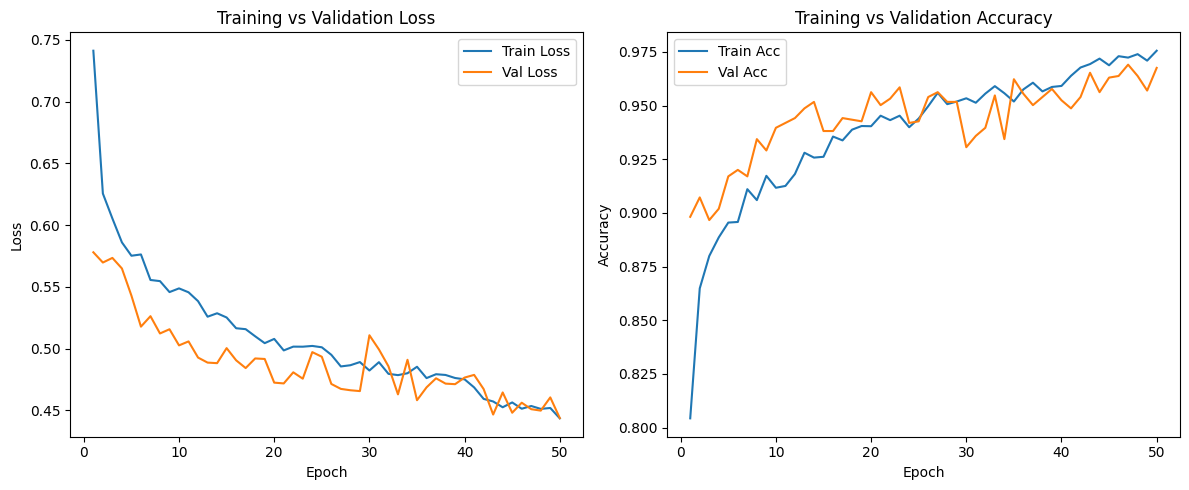

In [ ]:
history_path = "/content/drive/MyDrive/CS659 Project/results/resnet_history.csv"

# Load full history from CSV
history = pd.read_csv(history_path)

# Extract columns
epochs        = history["epoch"]
train_losses  = history["train_loss"]
val_losses    = history["val_loss"]
train_accs    = history["train_acc"]
val_accs      = history["val_acc"]


plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs,   label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS659 Project/results/resnet_history.png')
plt.show()

In [ ]:
# Testing
# Load checkpoint
ckpt = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(ckpt["model_state"])
print("Loaded model from checkpoint at epoch", ckpt["epoch"])

model.eval()

Loaded model from checkpoint at epoch 47


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Test Accuracy: 0.9517
Test Macro Precision: 0.9524
Test Macro Recall:    0.9549
Test Macro F1-score:  0.9535
Saved test results from best epoch 47 to CSV.


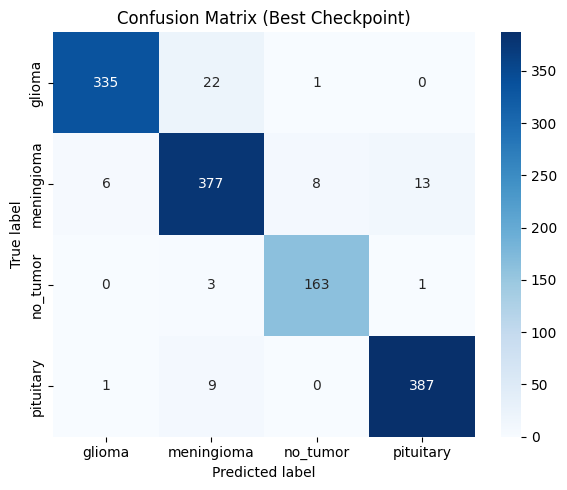

In [ ]:
all_preds = []
all_targets = []
img_save_dir = "/content/drive/MyDrive/CS659 Project/results/example_preds"
os.makedirs(img_save_dir, exist_ok=True)

saved = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

        for i in range(x.size(0)):
            if saved >= 20:   # limit to 20 examples
                break

            img = x[i].cpu()  # (C,H,W)
            pred = int(preds[i].cpu())
            true = int(y[i].cpu())

            # unnormalize if you used ImageNet normalization
            # img = img * torch.tensor(std).view(3,1,1) + torch.tensor(mean).view(3,1,1)
            img = img.permute(1, 2, 0).numpy()  # (H,W,C)

            plt.figure(figsize=(3,3))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Pred: {pred}, True: {true}")
            out_path = os.path.join(img_save_dir, f"example_{saved:03d}_pred{pred}_true{true}.png")
            plt.savefig(out_path, bbox_inches="tight")
            plt.close()
            saved += 1

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]  # or whatever your real names are
labels = np.array([0, 1, 2, 3])

# Metrics
acc = accuracy_score(all_targets, all_preds)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    all_targets, all_preds, average='macro'
)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro Precision: {prec_macro:.4f}")
print(f"Test Macro Recall:    {rec_macro:.4f}")
print(f"Test Macro F1-score:  {f1_macro:.4f}")

test_results = pd.DataFrame({
    "best_epoch": [ckpt["epoch"]],
    "accuracy": [acc],
    "precision": [prec_macro],
    "F1_score": [f1_macro]
})

test_results.to_csv("/content/drive/MyDrive/CS659 Project/results/test_results.csv", index=False)
print(f"Saved test results from best epoch {ckpt['epoch']} to CSV.")

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in labels],
            yticklabels=[class_names[i] for i in labels])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Best Checkpoint)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CS659 Project/results/test_confusion_matrix.png')
plt.show()